#INSTALASI PACKAGE

In [1]:
pip install ucimlrepo

#PEMANGGILAN LIBRARY

In [2]:
from ucimlrepo import fetch_ucirepo
import ucimlrepo
import pandas as pd


#MELIHAT DATASET YANG DISEDIAKAN

In [3]:
dir(ucimlrepo)

['API_BASE_URL',
 'API_LIST_URL',
 'DATASET_FILE_BASE_URL',
 'DatasetNotFoundError',
 'Optional',
 'VALID_FILTERS',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'certifi',
 'dotdict',
 'fetch',
 'fetch_ucirepo',
 'json',
 'list_available_datasets',
 'pd',
 'ssl',
 'urllib']

In [4]:
from ucimlrepo import list_available_datasets

In [5]:
datasets = list_available_datasets()

-------------------------------------
The following datasets are available:
-------------------------------------
Dataset Name                                                                            ID    
------------                                                                            --    
Abalone                                                                                 1     
Adult                                                                                   2     
Annealing                                                                               3     
Audiology (Standardized)                                                                8     
Auto MPG                                                                                9     
Automobile                                                                              10    
Balance Scale                                                                           12    
Balloons                       

In [19]:
data = fetch_ucirepo(id=571)

In [20]:
data

{'data': {'ids':       ID
  0      1
  1      2
  2      3
  3      4
  4      5
  ..   ...
  610  611
  611  612
  612  613
  613  614
  614  615
  
  [615 rows x 1 columns],
  'features':      Age Sex   ALB    ALP    AST   BIL    CHE  CHOL   CREA    CGT  PROT    ALT
  0     32   m  38.5   52.5   22.1   7.5   6.93  3.23  106.0   12.1  69.0    7.7
  1     32   m  38.5   70.3   24.7   3.9  11.17  4.80   74.0   15.6  76.5   18.0
  2     32   m  46.9   74.7   52.6   6.1   8.84  5.20   86.0   33.2  79.3   36.2
  3     32   m  43.2   52.0   22.6  18.9   7.33  4.74   80.0   33.8  75.7   30.6
  4     32   m  39.2   74.1   24.8   9.6   9.15  4.32   76.0   29.9  68.7   32.6
  ..   ...  ..   ...    ...    ...   ...    ...   ...    ...    ...   ...    ...
  610   62   f  32.0  416.6  110.3  50.0   5.57  6.30   55.7  650.9  68.5    5.9
  611   64   f  24.0  102.8   44.4  20.0   1.54  3.02   63.0   35.9  71.3    2.9
  612   64   f  29.0   87.3   99.0  48.0   1.66  3.63   66.7   64.2  82.0    3.5
  

#IMPORT LIBRARY

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

#LOAD DATA

In [21]:
df = data.data['original']

In [24]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ID        615 non-null    int64  
 1   Age       615 non-null    int64  
 2   Sex       615 non-null    object 
 3   ALB       614 non-null    float64
 4   ALP       597 non-null    float64
 5   ALT       614 non-null    float64
 6   AST       615 non-null    float64
 7   BIL       615 non-null    float64
 8   CHE       615 non-null    float64
 9   CHOL      605 non-null    float64
 10  CREA      615 non-null    float64
 11  CGT       615 non-null    float64
 12  PROT      614 non-null    float64
 13  Category  615 non-null    object 
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB
None
   ID  Age Sex   ALB   ALP   ALT  ...    CHE  CHOL   CREA   CGT  PROT       Category
0   1   32   m  38.5  52.5   7.7  ...   6.93  3.23  106.0  12.1  69.0  0=Blood Donor
1   2   32   m  38.5  70.3  18.0

#MISSING VALUES

In [25]:
imputer = SimpleImputer(strategy='mean')
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop(['ID'])  # Hindari ID
df[num_cols] = imputer.fit_transform(df[num_cols])

#ENCODE

In [26]:
df['Sex'] = LabelEncoder().fit_transform(df['Sex'])  # 'm'=1, 'f'=0
df['Category'] = df['Category'].str.extract(r'(\d)').astype(int)

In [27]:
X = df.drop(columns=['ID', 'Category'])  # Hindari pakai ID
y = df['Category']

#SPLIT DATA

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (492, 12)
Test shape: (123, 12)


#EDA (Exploratory Data Analysis)

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


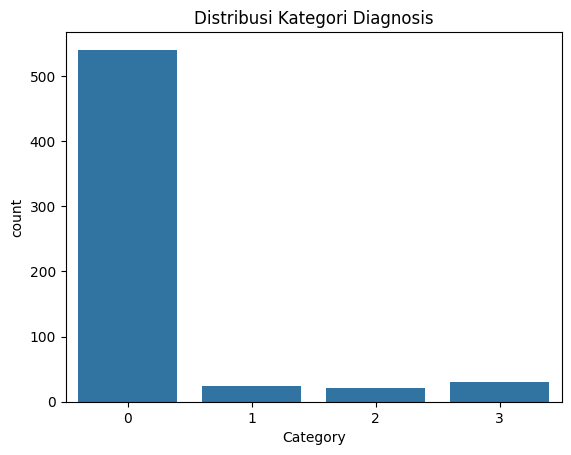

In [31]:
sns.countplot(x='Category', data=df)
plt.title('Distribusi Kategori Diagnosis')
plt.show()

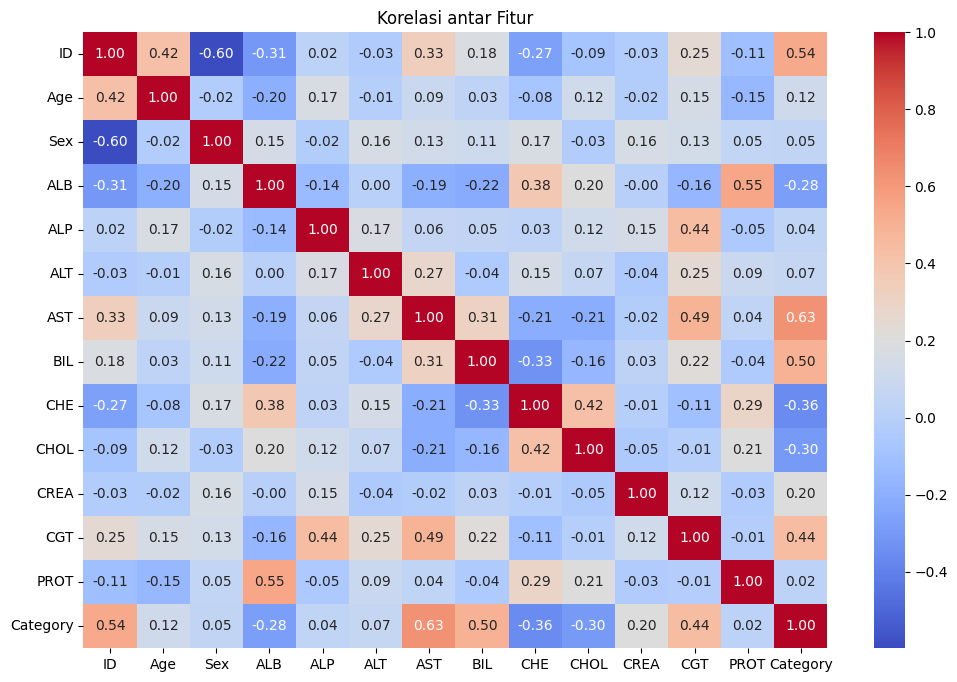

In [32]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi antar Fitur')
plt.show()

#Scaling (opsional)

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Modeling

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [36]:
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [37]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94        99
           1       1.00      0.11      0.20         9
           2       0.67      0.33      0.44         6
           3       0.88      0.78      0.82         9

    accuracy                           0.89       123
   macro avg       0.86      0.56      0.60       123
weighted avg       0.89      0.89      0.86       123



In [38]:
import numpy as np

#Visualisasi Penting

In [39]:
importances = clf.feature_importances_
indices = np.argsort(importances)[::-1]


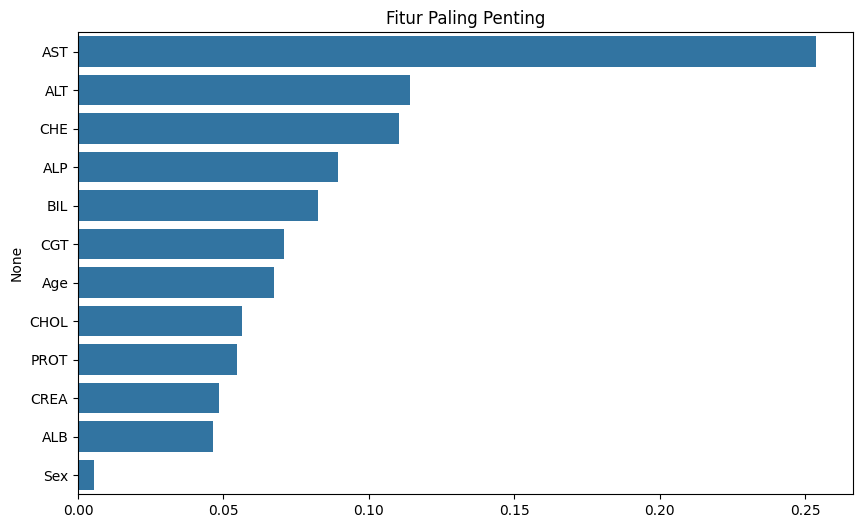

In [40]:
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title("Fitur Paling Penting")
plt.show()

#Cross-validation



In [41]:
from sklearn.model_selection import cross_val_score

In [42]:
scores = cross_val_score(clf, X, y, cv=5)
print("Akurasi rata-rata:", scores.mean())

Akurasi rata-rata: 0.9235772357723577
